### Problem Statement - Increasing patient satisfaction score with recommending appropriate preferred doctor

In [26]:
# ==============================================================
# Cell 1 — Setup & Imports
# ==============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# File path — update as needed
DATA_PATH="/Users/sriharikodam/Documents/IsbAMPBA/CapstoneProject/ClientData/Data/synthetic_encounters.csv"
DATA_PATHPatients="/Users/sriharikodam/Documents/IsbAMPBA/CapstoneProject/ClientData/Data/synthetic_patients.csv"
DATA_PATHProviders="/Users/sriharikodam/Documents/IsbAMPBA/CapstoneProject/ClientData/Data/synthetic_providers.csv"

print("Libraries imported and configuration ready.")

Libraries imported and configuration ready.


### Data Loading

In [27]:
# ==============================================================
# Cell 2 — Load Data
# ==============================================================

def load_data(path: str) -> pd.DataFrame:
    """
    Load the encounter dataset from CSV, infer dtypes, and basic cleaning.
    """
    df = pd.read_csv(path)
    print(f"Loaded dataset with shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")
    return df

dfEnc = load_data(DATA_PATH) #Encounter Data
dfPat = load_data(DATA_PATHPatients) #Patient Data
dfProv = load_data(DATA_PATHProviders) #Provider Data

Loaded dataset with shape: (200000, 17)
Columns: ['encounter_id', 'patient_id', 'provider_id', 'encounter_date', 'encounter_type', 'primary_diagnosis', 'length_of_stay', 'total_cost', 'cultural_background', 'primary_language', 'languages_spoken', 'cultural_competency_rating', 'cultural_match_score', 'language_match', 'patient_satisfaction', 'treatment_adherence', 'return_visit_30_days']
Loaded dataset with shape: (100000, 16)
Columns: ['patient_id', 'first_name', 'last_name', 'date_of_birth', 'gender', 'race', 'ethnicity', 'primary_language', 'zip_code', 'insurance_type', 'household_income', 'education_level', 'age', 'cultural_background', 'preferred_provider_language', 'cultural_preferences']
Loaded dataset with shape: (5000, 19)
Columns: ['provider_id', 'npi_number', 'first_name', 'last_name', 'specialty', 'practice_zip_code', 'years_experience', 'medical_school_country', 'board_certified', 'languages_spoken', 'interpreter_services', 'cultural_certifications', 'minority_health_experi

- List of provider data non repeated features

|Feature|Type of Category|
|-------|----------------|
|provided_id| ID column|
|npi_number|ID Column|
|first_name|String Column|
|last_name|String Column|
|speciality| Categorical|
|practice_zip_code|ID value|
|medical_School_country|categorical|
|boardcertifications|categorical|
|years_experience|binning categorical|
|cultural_certifications| categorical|
|minority_health_experience| categorical|
|community_involvement|categorical|
|patient_satisfaction_score| Ordinal value|
|communication_rating|ordinal value|
|cultural_competency_rating| ordinal value|
|hospital_affiliation|ID Column|
|accepts_new_patients|Binary Value|

#### Feature engineering of specialty,cultural_certifications,minority_health_experience,community_involvement,communication_rating,cultural_competency_rating,years_experience

In [ ]:
# ================================================
# Provider feature engineering (simple, line-by-line)
# ================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# Assume your raw providers DataFrame is named `prov`           
# If not, replace `prov` with your variable.

# --------------------------------
# 0) Columns of interest
# --------------------------------``
cat_cols = [
    "specialty",                   # categorical
    "cultural_certifications",     # categorical
    "minority_health_experience",  # categorical
    "community_involvement"        # categorical (lots of missing)
]
ordinal_cols = [
    # "patient_satisfaction_score",  # ordinal (e.g., 1–5)
    "communication_rating",        # ordinal (e.g., 1–5)
    "cultural_competency_rating"   # ordinal (e.g., 1–5)
]
years_col = "years_experience"     # to bin into categorical buckets

# --------------------------------
# 1) Basic cleaning for text categoricals
# --------------------------------
for c in cat_cols:
    if c in dfProv.columns:
        dfProv[c] = (
            dfProv[c].astype(str)
                   .str.strip()
                   .str.lower()
                   .replace({"nan": np.nan, "none": np.nan, "": np.nan})
        )

# --------------------------------
# 2) Handle missing categorical values
#    - For high-missing column (community_involvement), keep a missing flag.
#    - For others, fill with 'unknown'.
# --------------------------------
if "community_involvement" in dfProv.columns:
    dfProv["community_involvement_missing"] = dfProv["community_involvement"].isna().astype(int)
    dfProv["community_involvement"] = dfProv["community_involvement"].fillna("none")

for c in [c for c in cat_cols if c != "community_involvement"]:
    if c in dfProv.columns:
        dfProv[c] = dfProv[c].fillna("unknown")

# --------------------------------
# 3) Bin years_experience into categorical buckets
#    Example bins: [0,2), [2,5), [5,10), [10,20), [20,30), [30,+)
# --------------------------------
if years_col in dfProv.columns:
    dfProv[years_col] = pd.to_numeric(dfProv[years_col], errors="coerce")
    bins = [-0.001, 2, 5, 10, 20, 30, np.inf]
    labels = ["0-1", "2-4", "5-9", "10-19", "20-29", "30+"]
    dfProv["years_exp_bin"] = pd.cut(dfProv[years_col], bins=bins, labels=labels, right=True)
else:
    dfProv["years_exp_bin"] = pd.Series(pd.Categorical([]), index=dfProv.index)

# --------------------------------
# 4) Prepare One-Hot Encoding for categoricals (including years_exp_bin)
# --------------------------------
ohe_cols = [c for c in (cat_cols + ["years_exp_bin"]) if c in dfProv.columns]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    # for older sklearn versions
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

ohe_array = ohe.fit_transform(dfProv[ohe_cols])
ohe_names = ohe.get_feature_names_out(ohe_cols)
prov_ohe = pd.DataFrame(ohe_array, columns=ohe_names, index=dfProv.index)

# --------------------------------
# 5) Ordinal features: coerce to numeric and also create [0,1] scaled versions
#    (Keeps raw values + adds *_scaled for models expecting comparable magnitudes)
# --------------------------------
for c in ordinal_cols:
    if c not in dfProv.columns:
        # Create empty columns if missing
        dfProv[c] = np.nan

    # Coerce to numeric (keep NaN if not parseable)
    dfProv[c] = pd.to_numeric(dfProv[c], errors="coerce")

    # --- Global dense rank: higher value ⇒ better (rank=1 is top) ---
    # method='dense' gives consecutive ranks without gaps
    # ascending=False makes larger values get rank 1
    rank_col = f"{c}_rank_dense"
    dfProv[rank_col] = dfProv[c].rank(method="dense", ascending=False)

    # If all values are NaN, rank() returns all NaN; handle safely
    # Convert to Int64 (nullable integer) if you want integer ranks
    dfProv[rank_col] = dfProv[rank_col].astype("Int64")

    # --- Optional normalized rank in [0,1], with 1 = best ---
    # Normalize the dense ranks so that the best rank (1) maps to 1.0
    # and the worst rank maps to 0.0. Handles corner cases with one unique rank.
    norm_col = f"{c}_rank_dense_norm"
    # Compute max rank ignoring NaNs
    max_rank = dfProv[rank_col].max(skipna=True)

    if pd.notna(max_rank) and max_rank > 1:
        # 1 → 1.0; max_rank → 0.0
        dfProv[norm_col] = 1.0 - (dfProv[rank_col].astype("float") - 1.0) / (float(max_rank) - 1.0)
    elif pd.notna(max_rank) and max_rank == 1:
        # All values tied → everyone at 1.0
        dfProv[norm_col] = 1.0
    else:
        # All NaN case
        dfProv[norm_col] = np.nan

# --------------------------------
# 6) Assemble final feature set:
#    - Keep provider_id if present
#    - Keep raw ordinal + scaled versions
#    - Add OHE categorical features
#    - Add missing flag for community_involvement
# --------------------------------
keep_cols = []
if "provider_id" in dfProv.columns:
    keep_cols.append("provider_id")

keep_cols += [c for c in ordinal_cols if c in dfProv.columns]
keep_cols += [f"{c}_scaled" for c in ordinal_cols if f"{c}_scaled" in dfProv.columns]

if "community_involvement_missing" in dfProv.columns:
    keep_cols.append("community_involvement_missing")

prov_fe = pd.concat([dfProv[keep_cols], prov_ohe], axis=1)

# --------------------------------
# 7) Final cleanup: replace inf/NaN with 0 in numeric features (keep IDs intact)
# --------------------------------
num_cols = prov_fe.columns.difference(["provider_id"])
prov_fe[num_cols] = prov_fe[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# --------------------------------
# 8) Quick checks
# --------------------------------
print("prov_fe shape:", prov_fe.shape)
print("Sample columns:", list(prov_fe.columns)[:25])
prov_fe.head()

prov_fe shape: (5000, 36)
Sample columns: ['provider_id', 'communication_rating', 'cultural_competency_rating', 'community_involvement_missing', 'specialty_cardiology', 'specialty_emergency medicine', 'specialty_endocrinology', 'specialty_family medicine', 'specialty_gastroenterology', 'specialty_internal medicine', 'specialty_neurology', 'specialty_oncology', 'specialty_orthopedics', 'specialty_pediatrics', 'specialty_psychiatry', 'specialty_radiology', 'cultural_certifications_cross-cultural care certification', 'cultural_certifications_health equity training', 'cultural_certifications_joint commission cultural competency training', 'cultural_certifications_language services certification', 'cultural_certifications_minority health training certificate', 'cultural_certifications_ncqa cultural competency recognition', 'cultural_certifications_unknown', 'minority_health_experience_false', 'minority_health_experience_true']


,provider_id,communication_rating,cultural_competency_rating,community_involvement_missing,specialty_cardiology,specialty_emergency medicine,specialty_endocrinology,specialty_family medicine,specialty_gastroenterology,specialty_internal medicine,...,community_involvement_cultural health program,community_involvement_language access program,community_involvement_minority health initiative,community_involvement_none,years_exp_bin_0-1,years_exp_bin_10-19,years_exp_bin_2-4,years_exp_bin_20-29,years_exp_bin_30+,years_exp_bin_5-9
0,PROV_00001,4.571673,3.35,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,PROV_00002,4.162912,4.75,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,PROV_00003,4.460706,3.34,1,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,PROV_00004,5.000000,3.32,1,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,PROV_00005,5.000000,4.02,1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [29]:
# ============================================
# Provider feature engineering (line by line)
# ============================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# (Assumption) You already have: prov = pd.read_csv("providers.csv")
# Preview
# prov.head()

# -------------------------------
# 0) Define columns we will use
# -------------------------------
# Categorical
cat_specialty_col = "specialty"
cat_cultural_cert_col = "cultural_certifications"
cat_minority_health_col = "minority_health_experience"
cat_community_involvement_col = "community_involvement"  # lots of missing

# Ordinal (treat as numeric with ordered meaning)
ord_patient_sat_col = "patient_satisfaction_score"
ord_comm_rating_col = "communication_rating"
ord_cultural_comp_col = "cultural_competency_rating"

# Years (to bin → categorical)
years_exp_col = "years_experience"

# Keep provider_id if present
id_col = "provider_id" if "provider_id" in dfProv.columns else None

# =======================================================
# 1) specialty  (Categorical → clean text → fill → OHE)
# =======================================================
if cat_specialty_col in dfProv.columns:
    dfProv[cat_specialty_col] = (
        dfProv[cat_specialty_col]
        .astype(str).str.strip().str.lower()
        .replace({"nan": np.nan, "none": np.nan, "": np.nan})
        .fillna("unknown")
    )

# ====================================================================
# 2) years_experience  (Numeric → bin to categorical → later OHE)
# ====================================================================
if years_exp_col in dfProv.columns:
    dfProv[years_exp_col] = pd.to_numeric(dfProv[years_exp_col], errors="coerce")
    years_bins = [-0.001, 2, 5, 10, 20, 30, np.inf]  # edges
    years_labels = ["0-1", "2-4", "5-9", "10-19", "20-29", "30+"]
    dfProv["years_exp_bin"] = pd.cut(dfProv[years_exp_col], bins=years_bins, labels=years_labels, right=True)
else:
    dfProv["years_exp_bin"] = pd.Series(pd.Categorical(["unknown"] * len(dfProv)), index=dfProv.index)

# =====================================================================
# 3) cultural_certifications (Categorical → clean text → fill → OHE)
# =====================================================================
if cat_cultural_cert_col in dfProv.columns:
    dfProv[cat_cultural_cert_col] = (
        dfProv[cat_cultural_cert_col]
        .astype(str).str.strip().str.lower()
        .replace({"nan": np.nan, "none": np.nan, "": np.nan})
        .fillna("unknown")
    )

# =============================================================================
# 4) minority_health_experience (Categorical → clean text → fill → OHE)
# =============================================================================
if cat_minority_health_col in dfProv.columns:
    dfProv[cat_minority_health_col] = (
        dfProv[cat_minority_health_col]
        .astype(str).str.strip().str.lower()
        .replace({"nan": np.nan, "none": np.nan, "": np.nan})
        .fillna("unknown")
    )

# ======================================================================================
# 5) community_involvement (Categorical with many missing → flag missing → fill → OHE)
# ======================================================================================
if cat_community_involvement_col in dfProv.columns:
    dfProv["community_involvement_missing"] = dfProv[cat_community_involvement_col].isna().astype(int)
    dfProv[cat_community_involvement_col] = (
        dfProv[cat_community_involvement_col]
        .astype(str).str.strip().str.lower()
        .replace({"nan": np.nan, "none": np.nan, "": np.nan})
        .fillna("none")
    )
else:
    dfProv["community_involvement_missing"] = 0

# ==================================================================================
# 6) patient_satisfaction_score (Ordinal → coerce numeric → add 0–1 scaled version)
# ==================================================================================
if ord_patient_sat_col in dfProv.columns:
    dfProv[ord_patient_sat_col] = pd.to_numeric(dfProv[ord_patient_sat_col], errors="coerce")
    sat_min = dfProv[ord_patient_sat_col].min(skipna=True)
    sat_max = dfProv[ord_patient_sat_col].max(skipna=True)
    if pd.notna(sat_min) and pd.notna(sat_max) and sat_max > sat_min:
        dfProv[f"{ord_patient_sat_col}_scaled"] = (dfProv[ord_patient_sat_col] - sat_min) / (sat_max - sat_min)
    else:
        dfProv[f"{ord_patient_sat_col}_scaled"] = 0.0
else:
    dfProv[ord_patient_sat_col] = np.nan
    dfProv[f"{ord_patient_sat_col}_scaled"] = 0.0

# ========================================================================
# 7) communication_rating (Ordinal → numeric → add 0–1 scaled version)
# ========================================================================
if ord_comm_rating_col in dfProv.columns:
    dfProv[ord_comm_rating_col] = pd.to_numeric(dfProv[ord_comm_rating_col], errors="coerce")
    cr_min = dfProv[ord_comm_rating_col].min(skipna=True)
    cr_max = dfProv[ord_comm_rating_col].max(skipna=True)
    if pd.notna(cr_min) and pd.notna(cr_max) and cr_max > cr_min:
        dfProv[f"{ord_comm_rating_col}_scaled"] = (dfProv[ord_comm_rating_col] - cr_min) / (cr_max - cr_min)
    else:
        dfProv[f"{ord_comm_rating_col}_scaled"] = 0.0
else:
    dfProv[ord_comm_rating_col] = np.nan
    dfProv[f"{ord_comm_rating_col}_scaled"] = 0.0

# ==========================================================================================
# 8) cultural_competency_rating (Ordinal → numeric → add 0–1 scaled version)
# ==========================================================================================
if ord_cultural_comp_col in dfProv.columns:
    dfProv[ord_cultural_comp_col] = pd.to_numeric(dfProv[ord_cultural_comp_col], errors="coerce")
    cc_min = dfProv[ord_cultural_comp_col].min(skipna=True)
    cc_max = dfProv[ord_cultural_comp_col].max(skipna=True)
    if pd.notna(cc_min) and pd.notna(cc_max) and cc_max > cc_min:
        dfProv[f"{ord_cultural_comp_col}_scaled"] = (dfProv[ord_cultural_comp_col] - cc_min) / (cc_max - cc_min)
    else:
        dfProv[f"{ord_cultural_comp_col}_scaled"] = 0.0
else:
    dfProv[ord_cultural_comp_col] = np.nan
    dfProv[f"{ord_cultural_comp_col}_scaled"] = 0.0

# ==========================================================
# 9) One-Hot Encode the categorical columns (incl. years bin)
# ==========================================================
ohe_cols = []
if cat_specialty_col in dfProv.columns:            ohe_cols.append(cat_specialty_col)
if cat_cultural_cert_col in dfProv.columns:        ohe_cols.append(cat_cultural_cert_col)
if cat_minority_health_col in dfProv.columns:      ohe_cols.append(cat_minority_health_col)
if cat_community_involvement_col in dfProv.columns:ohe_cols.append(cat_community_involvement_col)
if "years_exp_bin" in dfProv.columns:              ohe_cols.append("years_exp_bin")

# Prepare the encoder (compatibility with older sklearn)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# Fit & transform (if no OHE columns exist, create empty frame)
if len(ohe_cols) > 0:
    ohe_array = ohe.fit_transform(dfProv[ohe_cols])
    ohe_names = ohe.get_feature_names_out(ohe_cols)
    prov_ohe = pd.DataFrame(ohe_array, columns=ohe_names, index=dfProv.index)
else:
    prov_ohe = pd.DataFrame(index=dfProv.index)

# ========================================================================
# 10) Assemble final engineered frame (ID + ordinal raw/scaled + OHE + flags)
# ========================================================================
keep_cols = []
if id_col: keep_cols.append(id_col)

# keep raw + scaled ordinal columns
keep_cols += [c for c in [ord_patient_sat_col, ord_comm_rating_col, ord_cultural_comp_col] if c in dfProv.columns]
keep_cols += [c for c in [f"{ord_patient_sat_col}_scaled",
                          f"{ord_comm_rating_col}_scaled",
                          f"{ord_cultural_comp_col}_scaled"] if c in dfProv.columns]

# keep missingness indicator for community involvement
if "community_involvement_missing" in dfProv.columns:
    keep_cols.append("community_involvement_missing")

# concatenate
prov_fe = pd.concat([dfProv[keep_cols], prov_ohe], axis=1)

# Clean numeric NaNs/Infs (leave provider_id untouched)
num_cols = prov_fe.columns.difference([id_col]) if id_col else prov_fe.columns
prov_fe[num_cols] = prov_fe[num_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# Final checks
print("Final engineered shape:", prov_fe.shape)
print("Sample columns:", list(prov_fe.columns)[:30])
prov_fe.head()

Final engineered shape: (5000, 40)
Sample columns: ['provider_id', 'patient_satisfaction_score', 'communication_rating', 'cultural_competency_rating', 'patient_satisfaction_score_scaled', 'communication_rating_scaled', 'cultural_competency_rating_scaled', 'community_involvement_missing', 'specialty_cardiology', 'specialty_emergency medicine', 'specialty_endocrinology', 'specialty_family medicine', 'specialty_gastroenterology', 'specialty_internal medicine', 'specialty_neurology', 'specialty_oncology', 'specialty_orthopedics', 'specialty_pediatrics', 'specialty_psychiatry', 'specialty_radiology', 'cultural_certifications_cross-cultural care certification', 'cultural_certifications_health equity training', 'cultural_certifications_joint commission cultural competency training', 'cultural_certifications_language services certification', 'cultural_certifications_minority health training certificate', 'cultural_certifications_ncqa cultural competency recognition', 'cultural_certifications_u

,provider_id,patient_satisfaction_score,communication_rating,cultural_competency_rating,patient_satisfaction_score_scaled,communication_rating_scaled,cultural_competency_rating_scaled,community_involvement_missing,specialty_cardiology,specialty_emergency medicine,...,community_involvement_cultural health program,community_involvement_language access program,community_involvement_minority health initiative,community_involvement_none,years_exp_bin_0-1,years_exp_bin_10-19,years_exp_bin_2-4,years_exp_bin_20-29,years_exp_bin_30+,years_exp_bin_5-9
0,PROV_00001,4.075961,4.571673,3.35,0.692835,0.848694,0.083333,0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,PROV_00002,4.293616,4.162912,4.75,0.765187,0.704300,0.861111,0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,PROV_00003,3.332870,4.460706,3.34,0.445821,0.809495,0.077778,0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,PROV_00004,3.665661,5.000000,3.32,0.556445,1.000000,0.066667,0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,PROV_00005,3.330108,5.000000,4.02,0.444903,1.000000,0.455556,0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0


In [30]:
SomCols=['provider_id',
       'communication_rating',
       'cultural_competency_rating', 'patient_satisfaction_score_scaled',
       'communication_rating_scaled', 'cultural_competency_rating_scaled',
       'community_involvement_missing', 'specialty_cardiology',
       'specialty_emergency medicine', 'specialty_endocrinology',
       'specialty_family medicine', 'specialty_gastroenterology',
       'specialty_internal medicine', 'specialty_neurology',
       'specialty_oncology', 'specialty_orthopedics', 'specialty_pediatrics',
       'specialty_psychiatry', 'specialty_radiology',
       'cultural_certifications_cross-cultural care certification',
       'cultural_certifications_health equity training',
       'cultural_certifications_joint commission cultural competency training',
       'cultural_certifications_language services certification',
       'cultural_certifications_minority health training certificate',
       'cultural_certifications_ncqa cultural competency recognition',
       'cultural_certifications_unknown', 'minority_health_experience_false',
       'minority_health_experience_true',
       'community_involvement_community health center',
       'community_involvement_cultural health program',
       'community_involvement_language access program',
       'community_involvement_minority health initiative',
       'community_involvement_none', 'years_exp_bin_0-1',
       'years_exp_bin_10-19', 'years_exp_bin_2-4', 'years_exp_bin_20-29',
       'years_exp_bin_30+', 'years_exp_bin_5-9']

In [31]:
# prov_fe[reqCols]

In [32]:
# ============================================
# Aggregate ENCOUNTER-level df → PATIENT–PROVIDER level
# Rules:
# - Categorical columns  → most frequent (mode)
# - length_of_stay       → max
# - Ratings (e.g., patient_satisfaction, cultural_competency_rating) → max
# - Scores / proportions (e.g., cultural_match_score, treatment_adherence, return_visit_30_days, language_match) → mean
# - total_cost           → mean (change to sum/median if you prefer)
# - Also keep: encounters count, last encounter_date
# ============================================

import numpy as np
import pandas as pd

# 0) Ensure df has at least these columns (adjust if your schema differs)
#    ['encounter_id','patient_id','provider_id','encounter_date',
#     'encounter_type','primary_diagnosis','length_of_stay','total_cost',
#     'cultural_background','primary_language','languages_spoken',
#     'cultural_competency_rating','cultural_match_score','language_match',
#     'patient_satisfaction','treatment_adherence','return_visit_30_days']

# 1) Keys for aggregation (patient–provider pairs)
keys = ["patient_id", "provider_id"]

# 2) Make a working copy and coerce types where needed
d = dfEnc.copy()
d["encounter_date"] = pd.to_datetime(d["encounter_date"], errors="coerce")

for c in ["length_of_stay","total_cost","cultural_competency_rating","cultural_match_score",
          "language_match","patient_satisfaction","treatment_adherence","return_visit_30_days"]:
    if c in d.columns:
        d[c] = pd.to_numeric(d[c], errors="coerce")

# 3) Helpers for mode (most frequent) with safe fallback
_mode = lambda s: s.mode().iat[0] if not s.mode().empty else np.nan

# 4) Encounters count per patient–provider
agg_cnt = d.groupby(keys, as_index=False)["encounter_id"].count().rename(columns={"encounter_id":"encounters"})

# 5) Last encounter date (max)
agg_last_dt = d.groupby(keys, as_index=False)["encounter_date"].max().rename(columns={"encounter_date":"last_encounter_date"})

# 6) Max length_of_stay
agg_los_max = d.groupby(keys, as_index=False)["length_of_stay"].max().rename(columns={"length_of_stay":"length_of_stay"})

# 7) Mean total_cost
agg_cost_mean = d.groupby(keys, as_index=False)["total_cost"].mean().rename(columns={"total_cost":"total_cost"})

# 8) Ratings → max
agg_rating_ps = d.groupby(keys, as_index=False)["patient_satisfaction"].max().rename(columns={"patient_satisfaction":"patient_satisfaction"})
agg_rating_cc = d.groupby(keys, as_index=False)["cultural_competency_rating"].max().rename(columns={"cultural_competency_rating":"cultural_competency_rating"})

# 9) Scores / proportions → mean
agg_match_mean   = d.groupby(keys, as_index=False)["cultural_match_score"].mean().rename(columns={"cultural_match_score":"cultural_match_score"})
agg_adher_mean   = d.groupby(keys, as_index=False)["treatment_adherence"].mean().rename(columns={"treatment_adherence":"treatment_adherence"})
agg_return_mean  = d.groupby(keys, as_index=False)["return_visit_30_days"].mean().rename(columns={"return_visit_30_days":"return_visit_30_days"})
agg_langmatch_mean = d.groupby(keys, as_index=False)["language_match"].mean().rename(columns={"language_match":"language_match"})

# 10) Categorical → most frequent (mode)
agg_enc_type = d.groupby(keys, as_index=False)["encounter_type"].agg(_mode).rename(columns={"encounter_type":"encounter_type"})
agg_dx_mode  = d.groupby(keys, as_index=False)["primary_diagnosis"].agg(_mode).rename(columns={"primary_diagnosis":"primary_diagnosis"})
agg_cult_bg  = d.groupby(keys, as_index=False)["cultural_background"].agg(_mode).rename(columns={"cultural_background":"cultural_background"})
agg_lang_prim= d.groupby(keys, as_index=False)["primary_language"].agg(_mode).rename(columns={"primary_language":"primary_language"})
agg_lang_spk = d.groupby(keys, as_index=False)["languages_spoken"].agg(_mode).rename(columns={"languages_spoken":"languages_spoken"})

# 11) Merge all aggregates into a single patient–provider DataFrame
dfEnc_encoded = agg_cnt.merge(agg_last_dt, on=keys, how="left")\
            .merge(agg_los_max, on=keys, how="left")\
            .merge(agg_cost_mean, on=keys, how="left")\
            .merge(agg_rating_ps, on=keys, how="left")\
            .merge(agg_rating_cc, on=keys, how="left")\
            .merge(agg_match_mean, on=keys, how="left")\
            .merge(agg_adher_mean, on=keys, how="left")\
            .merge(agg_return_mean, on=keys, how="left")\
            .merge(agg_langmatch_mean, on=keys, how="left")\
            .merge(agg_enc_type, on=keys, how="left")\
            .merge(agg_dx_mode,  on=keys, how="left")\
            .merge(agg_cult_bg,  on=keys, how="left")\
            .merge(agg_lang_prim,on=keys, how="left")\
            .merge(agg_lang_spk, on=keys, how="left")

# 12) Optional: recent_days per pair (min days since = most recent) — if you want recency
# latest_date = d["encounter_date"].max()
# d["recency_days"] = (latest_date - d["encounter_date"]).dt.days
# agg_recency_min = d.groupby(keys, as_index=False)["recency_days"].min().rename(columns={"recency_days":"recent_days"})
# pp = pp.merge(agg_recency_min, on=keys, how="left")

# 13) Final check
print(dfEnc_encoded.shape)
dfEnc_encoded.head()

(199964, 17)


,patient_id,provider_id,encounters,last_encounter_date,length_of_stay,total_cost,patient_satisfaction,cultural_competency_rating,cultural_match_score,treatment_adherence,return_visit_30_days,language_match,encounter_type,primary_diagnosis,cultural_background,primary_language,languages_spoken
0,PAT_000001,PROV_04499,1,2025-03-17 19:28:51.654206,5,1651.0,4.51,3.37,0.837,0.912,0.161,1.0,Telehealth,Back Pain,European American,English,English
1,PAT_000001,PROV_04538,1,2024-06-30 19:28:51.662524,2,1387.0,4.36,3.89,0.889,0.946,0.125,1.0,Office Visit,Asthma,European American,English,English; Spanish
2,PAT_000002,PROV_02628,1,2025-02-21 19:28:51.706079,0,16076.0,4.66,4.59,0.959,0.955,0.201,1.0,Office Visit,Arthritis,Hispanic/Latino,English,English; Arabic
3,PAT_000003,PROV_03728,1,2023-12-04 19:28:51.533494,4,816.0,4.08,3.40,0.540,0.757,0.176,0.0,Emergency,Hyperlipidemia,Asian American,Chinese,English
4,PAT_000004,PROV_00139,1,2023-12-25 19:28:51.723617,1,32815.0,4.44,4.16,0.616,0.771,0.173,0.0,Office Visit,Hyperlipidemia,European American,Spanish,English; Vietnamese


In [33]:
# --- Minimal, line-by-line snippet (no functions) ---
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

# Assume your DataFrame is named `df` and has at least:
# ['patient_id', 'patient_satisfaction']  (and optionally 'gender')

# 1) Make sure the score is numeric
dfEnc_encoded['patient_satisfaction'] = pd.to_numeric(dfEnc_encoded['patient_satisfaction'], errors='coerce')

# 2) Compute DENSE RANK within each patient (higher satisfaction = rank 1)
dfEnc_encoded['dense_rank'] = (
    dfEnc_encoded.groupby('patient_id')['patient_satisfaction']
      .rank(method='dense', ascending=False).fillna(0)
      .astype(int)
)

# 3) Turn the rank into an ordered categorical label like r1, r2, r3, ...
dfEnc_encoded['dense_rank_cat'] = 'r' + dfEnc_encoded['dense_rank'].astype(str)

# 1) Rename primary_language -> provider_language
dfEnc_encoded = dfEnc_encoded.rename(columns={"primary_language": "provider_language"})

# 4) Build the category order explicitly (ensures OrdinalEncoder follows rank order)
rank_levels_sorted = sorted(dfEnc_encoded['dense_rank'].unique())               # e.g., [1,2,3,...]
rank_categories = [['r' + str(x) for x in rank_levels_sorted]]       # e.g., [['r1','r2','r3',...]]

# 5) Ordinal-encode the rank category to integers starting at 0 (r1->0, r2->1, ...)
enc_rank = OrdinalEncoder(categories=rank_categories)
dfEnc_encoded[['dense_rank_enc']] = enc_rank.fit_transform(dfEnc_encoded[['dense_rank_cat']]).astype(int)

### # 1) Make sure the score is numeric
dfEnc_encoded['cultural_competency_rating'] = pd.to_numeric(dfEnc_encoded['cultural_competency_rating'], errors='coerce')

# 2) Compute DENSE RANK within each patient (higher satisfaction = rank 1)
dfEnc_encoded['dense_rank_culturalComp'] = (
    dfEnc_encoded.groupby('patient_id')['cultural_competency_rating']
      .rank(method='dense', ascending=False).fillna(0)
      .astype(int)
)

# 3) Turn the rank into an ordered categorical label like r1, r2, r3, ...
dfEnc_encoded['dense_rank_cat_culturalComp'] = 'r' + dfEnc_encoded['dense_rank_culturalComp'].astype(str)

# 4) Build the category order explicitly (ensures OrdinalEncoder follows rank order)
rank_levels_sorted = sorted(dfEnc_encoded['dense_rank_culturalComp'].unique())               # e.g., [1,2,3,...]
rank_categories = [['r' + str(x) for x in rank_levels_sorted]]       # e.g., [['r1','r2','r3',...]]

# 5) Ordinal-encode the rank category to integers starting at 0 (r1->0, r2->1, ...)
enc_rank = OrdinalEncoder(categories=rank_categories)
dfEnc_encoded['dense_rank_enc_culturalComp'] = enc_rank.fit_transform(dfEnc_encoded[['dense_rank_cat_culturalComp']]).astype(int)
######

# 1) Rename primary_language -> provider_language
dfEnc_encoded = dfEnc_encoded.rename(columns={"primary_language": "provider_language"})

# (Optional) If you also want to encode gender as ordinal: female < male
# Normalize to lowercase to avoid mismatches
if 'gender' in dfEnc_encoded.columns:
    dfEnc_encoded['gender'] = dfEnc_encoded['gender'].astype(str).str.strip().str.lower()

    # 2) Apply OneHotEncoder (dense output for simplicity)
    ohe_gender = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # 3) Fit and transform the gender column
    gender_encoded = ohe_gender.fit_transform(dfEnc_encoded[['gender']])

    # 4) Get the column names like gender_female, gender_male, etc.
    gender_ohe_cols = [f"gender_{cat}" for cat in ohe_gender.categories_[0]]

    # 5) Add back to the DataFrame
    dfEnc_encoded[gender_ohe_cols] = gender_encoded

    # 6) (Optional) Drop the original gender column if not needed
    dfEnc_encoded = dfEnc_encoded.drop(columns=['gender'])


# 6) (Optional) Drop helper columns if you only want the encoded result
# df = df.drop(columns=['dense_rank', 'dense_rank_cat'])

# 7) Quick sanity check
print(dfEnc_encoded[['patient_id', 'patient_satisfaction', 'dense_rank', 'dense_rank_cat', 'dense_rank_enc','dense_rank_enc_culturalComp']].head())
# If gender used: print(df[['gender','gender_enc']].drop_duplicates().head())

   patient_id  patient_satisfaction  dense_rank dense_rank_cat  \
0  PAT_000001                  4.51           1             r1   
1  PAT_000001                  4.36           2             r2   
2  PAT_000002                  4.66           1             r1   
3  PAT_000003                  4.08           1             r1   
4  PAT_000004                  4.44           1             r1   

   dense_rank_enc  dense_rank_enc_culturalComp  
0               0                            1  
1               1                            0  
2               0                            0  
3               0                            0  
4               0                            0  


In [34]:
import pandas as pd
import numpy as np

# If not already defined:
DATE_COL = "encounter_date"
ORDINAL_COLS = ["cultural_competency_rating", "patient_satisfaction"]  # adjust if needed

# # 1) Ensure datetime
# df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

# # 2) Recency in days (days since most recent encounter in the data)
# _max_date = df[DATE_COL].max()
# df["recency_days"] = (_max_date - df[DATE_COL]).dt.days

# 3) Cultural match score → percentage (if present; tolerant to existing 0–100 or 0–1)
if "cultural_match_score" in dfEnc_encoded.columns:
    dfEnc_encoded["cultural_match_score"] = pd.to_numeric(dfEnc_encoded["cultural_match_score"], errors="coerce")
    # If values look like proportions (<=1.5), convert to percent; else keep as-is
    _cms_max = dfEnc_encoded["cultural_match_score"].dropna().max()
    dfEnc_encoded["cultural_match_score"] = np.where(
        (_cms_max is not np.nan) & (dfEnc_encoded["cultural_match_score"] <= 1.5),
        dfEnc_encoded["cultural_match_score"] * 100.0,
        dfEnc_encoded["cultural_match_score"]
    )

# 5) Binary column cleanup (cast to 0/1 int if present)
if "language_match" in dfEnc_encoded.columns:
    # dfEnc_encoded["language_match"] = pd.to_numeric(dfEnc_encoded["language_match"], errors="coerce").fillna(0)
    # Map common textual/bool variants to d/1 then cast
    dfEnc_encoded["language_match"] = dfEnc_encoded["language_match"].replace({True:1, False:0})
    dfEnc_encoded["language_match"] = dfEnc_encoded["language_match"].astype(int)

# 6) Quick peek
dfEnc_encoded.head()

,patient_id,provider_id,encounters,last_encounter_date,length_of_stay,total_cost,patient_satisfaction,cultural_competency_rating,cultural_match_score,treatment_adherence,...,primary_diagnosis,cultural_background,provider_language,languages_spoken,dense_rank,dense_rank_cat,dense_rank_enc,dense_rank_culturalComp,dense_rank_cat_culturalComp,dense_rank_enc_culturalComp
0,PAT_000001,PROV_04499,1,2025-03-17 19:28:51.654206,5,1651.0,4.51,3.37,83.7,0.912,...,Back Pain,European American,English,English,1,r1,0,2,r2,1
1,PAT_000001,PROV_04538,1,2024-06-30 19:28:51.662524,2,1387.0,4.36,3.89,88.9,0.946,...,Asthma,European American,English,English; Spanish,2,r2,1,1,r1,0
2,PAT_000002,PROV_02628,1,2025-02-21 19:28:51.706079,0,16076.0,4.66,4.59,95.9,0.955,...,Arthritis,Hispanic/Latino,English,English; Arabic,1,r1,0,1,r1,0
3,PAT_000003,PROV_03728,1,2023-12-04 19:28:51.533494,4,816.0,4.08,3.40,54.0,0.757,...,Hyperlipidemia,Asian American,Chinese,English,1,r1,0,1,r1,0
4,PAT_000004,PROV_00139,1,2023-12-25 19:28:51.723617,1,32815.0,4.44,4.16,61.6,0.771,...,Hyperlipidemia,European American,Spanish,English; Vietnamese,1,r1,0,1,r1,0


In [35]:
# --- Simple, line-by-line feature engineering for categorical OHE ---

import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# Assumes your DataFrame is named `enc`
# Columns used: primary_diagnosis, encounter_type, cultural_background, languages_spoken, primary_language

# 2) Normalize text columns (strip + lowercase) for stable categories
for _c in ["primary_diagnosis", "encounter_type", "cultural_background", "provider_language", "languages_spoken"]:
    if _c in dfEnc_encoded.columns:
        dfEnc_encoded[_c] = dfEnc_encoded[_c].astype(str).str.strip().str.lower().replace({"nan": np.nan, "": np.nan})

# 3) Split languages_spoken into language_1 and language_2 (split by ';')
if "languages_spoken" in dfEnc_encoded.columns:
    _langs = dfEnc_encoded["languages_spoken"].fillna("").astype(str).str.split(";")
    dfEnc_encoded["language_1"] = _langs.apply(lambda x: x[0].strip().lower() if len(x) >= 1 and x[0].strip() != "" else np.nan)
    dfEnc_encoded["language_2"] = _langs.apply(lambda x: x[1].strip().lower() if len(x) >= 2 and x[1].strip() != "" else "none")
else:
    dfEnc_encoded["language_1"] = np.nan
    dfEnc_encoded["language_2"] = "none"

# 4) Choose categorical columns to one-hot encode
cat_cols = [
    "primary_diagnosis",
    "encounter_type",
    "cultural_background",
    "language_1",
    "language_2",
    "provider_language"
]

# 5) Impute missing with most frequent (mode) per column (simple, inline)
for _c in cat_cols:
    if _c in dfEnc_encoded.columns:
        _series = dfEnc_encoded[_c]
        if _series.dropna().empty:
            _mode = "unknown"
        else:
            _mode = _series.mode(dropna=True).iloc[0]
        dfEnc_encoded[_c] = _series.fillna(_mode)
    else:
        dfEnc_encoded[_c] = "unknown"

# 6) OneHotEncode the selected categorical columns (dense output for simplicity)
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn >= 1.2
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)         # sklearn < 1.2

X_cat = ohe.fit_transform(dfEnc_encoded[cat_cols])
ohe_cols = ohe.get_feature_names_out(cat_cols)

# 7) Create a DataFrame for the encoded features and align indices
df_ohe = pd.DataFrame(X_cat, columns=ohe_cols, index=dfEnc_encoded.index)

# 8) Concatenate back and (optionally) drop original categorical columns
dfEnc_encoded = pd.concat([dfEnc_encoded.drop(columns=["languages_spoken"] + cat_cols, errors="ignore"), df_ohe], axis=1)

In [36]:
import numpy as np
import pandas as pd

# Assume your dataframe name is enc

# 1) Convert total_cost to numeric (in case it has strings or missing values)
dfEnc_encoded["total_cost"] = pd.to_numeric(dfEnc_encoded["total_cost"], errors="coerce")

# 2) Apply log transformation: log1p handles zeros safely (log(1 + x))
dfEnc_encoded["total_cost_log"] = np.log1p(dfEnc_encoded["total_cost"])

# # 3) Convert length_of_stay to numeric
# dfEnc_encoded["length_of_stay"] = pd.to_numeric(dfEnc_encoded["length_of_stay"], errors="coerce")

# # 4) Define bin edges and labels
# bin_edges = [-np.inf, 1, 3, 7, 14, np.inf]
# bin_labels = ["<=1d", "2-3d", "4-7d", "8-14d", ">14d"]

# # 5) Create binned variable using pd.cut
# dfEnc_encoded["length_of_stay_bin"] = pd.cut(dfEnc_encoded["length_of_stay"], bins=bin_edges, labels=bin_labels)

# dfEnc_encoded["length_of_stay_bin"] = dfEnc_encoded["length_of_stay_bin"].astype(str).str.strip().replace({"nan": np.nan})

# dfEnc_encoded["length_of_stay_bin"] = dfEnc_encoded["length_of_stay_bin"].fillna("unknown")

# # 3) Initialize OneHotEncoder (dense output for simplicity)
# try:
#     ohe_los = OneHotEncoder(handle_unknown="ignore", sparse_output=False)  # sklearn ≥1.2
# except TypeError:
#     ohe_los = OneHotEncoder(handle_unknown="ignore", sparse=False)         # sklearn <1.2

# # 4) Fit & transform the length_of_stay_bin column
# los_encoded = ohe_los.fit_transform(dfEnc_encoded[["length_of_stay_bin"]])

# # 5) Get encoded column names?
# los_ohe_cols = [f"length_of_stay_bin_{cat}" for cat in ohe_los.categories_[0]]

# # 6) Create a DataFrame for encoded columns
# df_los_ohe = pd.DataFrame(los_encoded, columns=los_ohe_cols, index=dfEnc_encoded.index)

# # Safest: assign each encoded column directly without full concat
# for col in df_los_ohe.columns:
#     dfEnc_encoded[col] = df_los_ohe[col].astype("float32")

# # Now drop the original column after adding
# if "length_of_stay_bin" in dfEnc_encoded.columns:
#     dfEnc_encoded.drop(columns=["length_of_stay_bin"], inplace=True)

In [37]:
# ==========================================================
# Categorical Encoding — Simple Notebook Style
# ==========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

# 1️⃣ Define categorical columns
catCols = [
    'gender',
    'race',
    'ethnicity',
    'primary_language',
    'insurance_type',
    'education_level',
    'cultural_background',
    'preferred_provider_language',
    # 'cultural_preferences'
]

#Note -- Removed Cultural Preferences.

# 2️⃣ Convert to lowercase and strip whitespace for consistent categories
for col in catCols:
    if col in dfPat.columns:
        dfPat[col] = (
            dfPat[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .replace({"nan": np.nan, "none": np.nan, "": np.nan})
        )

# 3️⃣ Fill missing categorical values with a placeholder (e.g., 'unknown')
for col in catCols:
    if col in dfPat.columns:
        dfPat[col] = dfPat[col].fillna("unknown")

# 6️⃣ Initialize OneHotEncoder
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

# 7️⃣ Fit and transform the categorical columns
encoded_array = ohe.fit_transform(dfPat[catCols])

# 8️⃣ Get encoded feature names
encoded_names = ohe.get_feature_names_out(catCols)

# 9️⃣ Create a DataFrame for the encoded features
encoded_df = pd.DataFrame(encoded_array, columns=encoded_names, index=dfPat.index)

dfPat["household_income_log"] = np.log1p(dfPat["household_income"])

# 🔟 Merge encoded features back to original DataFrame
dfPat_encoded = pd.concat([dfPat.drop(columns=catCols, errors="ignore"), encoded_df], axis=1)

# 11️⃣ Clean up — replace any infinities or NaNs with 0
dfPat_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)
dfPat_encoded.fillna(0, inplace=True)

# 12️⃣ Quick check
print("Original shape:", dfPat.shape)
print("Encoded shape:", dfPat_encoded.shape)
dfPat_encoded.head()

Original shape: (100000, 17)
Encoded shape: (100000, 50)


,patient_id,first_name,last_name,date_of_birth,zip_code,household_income,age,cultural_preferences,household_income_log,gender_f,...,cultural_background_native american,cultural_background_other/mixed,preferred_provider_language_arabic,preferred_provider_language_chinese,preferred_provider_language_english,preferred_provider_language_korean,preferred_provider_language_portuguese,preferred_provider_language_russian,preferred_provider_language_spanish,preferred_provider_language_vietnamese
0,PAT_000001,Carmen,Brown,1951-02-02 19:28:50.538957,88871,101205,74,No Specific Preference,11.524913,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,PAT_000002,Jose,Hassan,2002-04-12 19:28:50.538972,15903,122761,23,Culturally Similar Provider,11.718003,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,PAT_000003,Joseph,Williams,2005-06-20 19:28:50.538975,46986,46074,20,Culturally Similar Provider; Same Language Pro...,10.738026,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,PAT_000004,Linda,Ali,1976-06-15 19:28:50.538976,91182,18071,49,Same Language Provider,9.802119,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,PAT_000005,Wei,Kim,1956-05-08 19:28:50.538978,92635,96263,69,Culturally Similar Provider,11.474850,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [38]:
# dfPat_encoded.shape,dfProveFe.shape

In [39]:
dfPat_encoded.columns

Index(['patient_id', 'first_name', 'last_name', 'date_of_birth', 'zip_code',
       'household_income', 'age', 'cultural_preferences',
       'household_income_log', 'gender_f', 'gender_m', 'race_asian',
       'race_black or african american', 'race_hispanic or latino',
       'race_native american', 'race_other', 'race_white',
       'ethnicity_hispanic or latino', 'ethnicity_not hispanic or latino',
       'primary_language_arabic', 'primary_language_chinese',
       'primary_language_english', 'primary_language_korean',
       'primary_language_portuguese', 'primary_language_russian',
       'primary_language_spanish', 'primary_language_vietnamese',
       'insurance_type_medicaid', 'insurance_type_medicare',
       'insurance_type_private', 'insurance_type_uninsured',
       'education_level_bachelor's', 'education_level_graduate',
       'education_level_high school', 'education_level_less than high school',
       'education_level_some college', 'cultural_background_african amer

In [40]:
dfEncPat_data=dfEnc_encoded.merge(dfPat_encoded,on="patient_id")
dfEncPatProv_data=dfEncPat_data.merge(prov_fe,on='provider_id')

In [41]:
dfEncPat_data.shape

(199964, 105)

In [42]:
dfEncPatProv_data.iloc[1]

patient_id                             PAT_000001
provider_id                            PROV_04538
encounters                                      1
last_encounter_date    2024-06-30 19:28:51.662524
length_of_stay                                  2
                                  ...            
years_exp_bin_10-19                           0.0
years_exp_bin_2-4                             0.0
years_exp_bin_20-29                           1.0
years_exp_bin_30+                             0.0
years_exp_bin_5-9                             0.0
Name: 1, Length: 144, dtype: object

In [43]:
dfEncPatProv_data[0:10].to_csv("Snark.csv")

In [44]:
notReqCols=['patient_id',
            'provider_id',
            'last_encounter_date',
            'length_of_stay',
            'total_cost',
            'cultural_competency_rating',
            'cultural_match_score',
            'treatment_adherence',
            'return_visit_30_days',
            'language_match',
            'dense_rank',
            'dense_rank_cat',
            'first_name',
            'last_name',
            'date_of_birth',
            'zip_code',
            'household_income',
            'age',
            'dense_rank_enc',
            'label_int',
            'patient_satisfaction',
            'gender_f',
            'gender_m',
            'total_cost_log',
            'household_income_log',
            'language_2_none',
            'first_name', 'last_name', 'date_of_birth',
            'zip_code', 'household_income', 'age','gender_f', 'gender_m','cultural_preferences',
            'patient_satisfaction_score',
            'cultural_competency_rating_x',
            'patient_satisfaction_score_scaled',
            'cultural_competency_rating_x',
            'cultural_competency_rating_y',
            'cultural_competency_rating_scaled',
            'communication_rating_scaled'
            ]

In [45]:
feature_cols= [c for c in dfEncPatProv_data.columns if c not in notReqCols]

In [46]:
feature_cols[50:]

['primary_language_english',
 'primary_language_korean',
 'primary_language_portuguese',
 'primary_language_russian',
 'primary_language_spanish',
 'primary_language_vietnamese',
 'insurance_type_medicaid',
 'insurance_type_medicare',
 'insurance_type_private',
 'insurance_type_uninsured',
 "education_level_bachelor's",
 'education_level_graduate',
 'education_level_high school',
 'education_level_less than high school',
 'education_level_some college',
 'cultural_background_african american_y',
 'cultural_background_asian american_y',
 'cultural_background_european american_y',
 'cultural_background_hispanic/latino_y',
 'cultural_background_native american_y',
 'cultural_background_other/mixed_y',
 'preferred_provider_language_arabic',
 'preferred_provider_language_chinese',
 'preferred_provider_language_english',
 'preferred_provider_language_korean',
 'preferred_provider_language_portuguese',
 'preferred_provider_language_russian',
 'preferred_provider_language_spanish',
 'preferred

In [47]:
train_merged = dfEncPatProv_data[feature_cols]
X = dfEncPatProv_data[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0).astype("float32").values
# encounter_max_rank = df.groupby("patient_id")["dense_rank_enc"].transform("max")
encounter_max_rank = dfEncPatProv_data.groupby("patient_id")["dense_rank_enc"].transform("max")
dfEncPatProv_data["label_int"] = np.where(dfEncPatProv_data["dense_rank_enc"] == encounter_max_rank, 1, 0)
groups_train = dfEncPatProv_data.groupby("patient_id").size().values
y = dfEncPatProv_data["label_int"].astype(int).values

In [48]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=dfEncPatProv_data["patient_id"]))
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = dfEncPatProv_data.iloc[train_idx].groupby("patient_id").size().values

In [49]:
# Count of zeros in y_train
print("Number of zeros in y_train:", (y_train == 0).sum())

# Optional: percentage of zeros
print("Percentage of zeros:", ((y_train == 0).sum() / len(y_train)) * 100, "%")

Number of zeros in y_train: 87744
Percentage of zeros: 54.887683675192825 %


In [50]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRanker
from xgboost import XGBRanker

# 14) Fit LGBMRanker
lgb = LGBMRanker(
    objective="lambdarank",
    metric="ndcg",
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)
lgb.fit(X_train, y_train, group=groups_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009693 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 493
[LightGBM] [Info] Number of data points in the train set: 159861, number of used features: 110


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [51]:
xgb = XGBRanker(
    objective="rank:ndcg",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.9,
    colsample_bytree=0.9,
    tree_method="hist",
    eval_metric="ndcg",
    random_state=42
)
xgb.fit(X_train, y_train, group=groups_train)

,objective,'rank:ndcg'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'ndcg'


In [52]:
scores_lgb = lgb.predict(X_test).astype(float)
# scores_xgb = xgb.predict(X_test).astype(float)

# 19) Rank providers per encounter — LGBM
N = 4  # top-N providers per encounter
rows_lgb = []
start = 0
for eid, g in dfEncPatProv_data.iloc[test_idx].groupby("patient_id", sort=False):
    n = len(g)
    stop = start + n
    sc = scores_lgb[start:stop]
    order = np.argsort(-sc)[:N]
    top = g.iloc[order][["patient_id","provider_id"]].copy()
    top["rank"]  = np.arange(1, len(top)+1)
    top["score"] = sc[order]
    rows_lgb.append(top)
    start = stop
rankings_lgb = pd.concat(rows_lgb, axis=0).reset_index(drop=True)

In [53]:
rankings_lgb

,patient_id,provider_id,rank,score
0,PAT_000029,PROV_02046,1,0.181739
1,PAT_000029,PROV_02178,2,0.025579
2,PAT_000029,PROV_00083,3,-0.144995
3,PAT_000029,PROV_03981,4,-0.174075
4,PAT_000040,PROV_01982,1,-0.118101
...,...,...,...,...
38518,PAT_099978,PROV_00091,1,0.124936
38519,PAT_099978,PROV_03609,2,-0.038822
38520,PAT_099994,PROV_02536,1,-0.036514
38521,PAT_099995,PROV_01840,1,-0.161671


In [54]:
# ===========================================
# Hyperparameter tuning for XGBRanker → maximize NDCG@10
# Group-aware CV by patient_id
# ===========================================

import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import ndcg_score
from xgboost import XGBRanker

# ---------- Inputs (already prepared) ----------
# X_train : features (np.ndarray or pd.DataFrame)
# y_train : graded relevance labels (np.ndarray of shape [n_samples])
# df_train: DataFrame aligned to X_train rows, must contain 'patient_id'
# ------------------------------------------------

# 1) Helper: build group sizes (counts per patient) for any row-index subset
def group_sizes_for_index(df_like, index, group_col="patient_id"):
    gcounts = df_like.loc[index, group_col].value_counts()
    # XGB expects an array of counts in the *current order of groups* as they appear in the data.
    # We'll reconstruct in data order:
    grp_order = df_like.loc[index, group_col].groupby(df_like.loc[index, group_col]).head(1).index
    # Actually simpler: compute sizes by iterating through contiguous blocks of same group:
    # (works because we'll sort by patient_id per fold)
    return df_like.loc[index, group_col].groupby(df_like.loc[index, group_col]).size().values

# 2) We’ll use GroupKFold for CV and sort rows within each split by patient_id to make group sizes contiguous.
gkf = GroupKFold(n_splits=3)
df_train=dfEncPatProv_data.iloc[train_idx].copy()
# groups_all = df_train["patient_id"]


# 1️⃣ Make sure 'patient_id' exists and has no missing values
df_train["patient_id"] = df_train["patient_id"].astype(str).fillna("unknown")

# 2️⃣ Map each unique patient_id → integer group id
df_train["patient_group"] = df_train["patient_id"].astype("category").cat.codes

# 3️⃣ Now use this integer array for grouping
groups_all = df_train["patient_group"].to_numpy()
y_train=y_train
print(len(groups_all))
print("X_train shape:", getattr(X_train, "shape", None))
print("y_train shape:", getattr(y_train, "shape", None))
print("df_train shape:", getattr(df_train, "shape", None))

# 3) Define a small random search space (feel free to widen ranges)
param_space = {
    "n_estimators":   [300, 500, 800, 1200],
    "learning_rate":  [0.03, 0.05, 0.07, 0.1],
    "max_depth":      [6, 8, 10],
    "min_child_weight":[1, 5, 10],
    "subsample":      [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree":[0.7, 0.8, 0.9, 1.0],
    "reg_alpha":      [0.0, 0.1, 0.5, 1.0],
    "reg_lambda":     [1.0, 2.0, 5.0, 10.0],
    "gamma":          [0.0, 0.1, 0.2]
}

# 4) Create random combinations
rng = np.random.default_rng(42)
def sample_params():
    return {k: rng.choice(v) for k, v in param_space.items()}

N_TRIALS = 5  # increase for a deeper search
best_ndcg = -np.inf
best_params = None
history = []

# 5) Random search with group-aware CV
for t in range(N_TRIALS):
    params = sample_params()

    cv_scores = []
    for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train, y_train, groups=groups_all)):
        # sort by patient for contiguous groups (helps when passing group sizes)
        tr_ord = np.argsort(df_train.iloc[tr_idx]["patient_id"].values, kind="mergesort")
        va_ord = np.argsort(df_train.iloc[va_idx]["patient_id"].values, kind="mergesort")
        tr_idx2 = tr_idx[tr_ord]
        va_idx2 = va_idx[va_ord]

        X_tr, y_tr = X_train[tr_idx2], y_train[tr_idx2]
        X_va, y_va = X_train[va_idx2], y_train[va_idx2]

        # group sizes for this fold (contiguous by patient_id)
        grp_tr = df_train.iloc[tr_idx2]["patient_id"].groupby(df_train.iloc[tr_idx2]["patient_id"]).size().values
        grp_va = df_train.iloc[va_idx2]["patient_id"].groupby(df_train.iloc[va_idx2]["patient_id"]).size().values

        model = XGBRanker(
            objective="rank:ndcg",
            eval_metric="ndcg@5",        # directly monitor ndcg@10
            tree_method="hist",
            random_state=42,
            n_jobs=-1,
            **params
        )

        # early stopping using the validation fold's groups
        model.fit(
            X_tr, y_tr,
            group=grp_tr,
            eval_set=[(X_va, y_va)],
            eval_group=[grp_va],
            verbose=False,
            # early_stopping_rounds=50
        )

        # predict scores and compute NDCG@10 per patient, then average
        # build per-patient slices for the validation fold
        va_groups = df_train.iloc[va_idx2]["patient_id"].values
        # accumulate mean ndcg across groups
        start = 0
        ndcgs = []
        # compute contiguous block sizes again (same as grp_va)
        sizes = grp_va
        for size in sizes:
            stop = start + size
            y_block = y_va[start:stop].reshape(1, -1)
            s_block = model.predict(X_va[start:stop]).reshape(1, -1)
            # skip degenerate blocks (size<2 or all equal labels)
            if size >= 2 and not np.all(y_block[0] == y_block[0][0]):
                ndcgs.append(ndcg_score(y_block, s_block, k=10))
            start = stop

        fold_ndcg = float(np.mean(ndcgs)) if ndcgs else 0.0
        cv_scores.append(fold_ndcg)

    mean_ndcg = float(np.mean(cv_scores))
    history.append((params, mean_ndcg))
    if mean_ndcg > best_ndcg:
        best_ndcg = mean_ndcg
        best_params = params
    print(f"Trial {t+1:02d}/{N_TRIALS}  mean NDCG@5 = {mean_ndcg:.5f}  params={params}")

print("\nBest CV NDCG@5:", round(best_ndcg, 5))
print("Best params:", best_params)

# 6) Fit final model on full training data with a small holdout for early stopping
#    (still group-aware; keeps patients separated)
gss = GroupShuffleSplit(test_size=0.15, n_splits=1, random_state=123)
tr_idx, va_idx = next(gss.split(X_train, y_train, groups=groups_all))

# order within splits by patient_id for contiguous groups
tr_ord = np.argsort(df_train.iloc[tr_idx]["patient_id"].values, kind="mergesort")
va_ord = np.argsort(df_train.iloc[va_idx]["patient_id"].values, kind="mergesort")
tr_idx2 = tr_idx[tr_ord]
va_idx2 = va_idx[va_ord]

X_tr, y_tr = X_train[tr_idx2], y_train[tr_idx2]
X_va, y_va = X_train[va_idx2], y_train[va_idx2]
grp_tr = df_train.iloc[tr_idx2]["patient_id"].groupby(df_train.iloc[tr_idx2]["patient_id"]).size().values
grp_va = df_train.iloc[va_idx2]["patient_id"].groupby(df_train.iloc[va_idx2]["patient_id"]).size().values

best_xgb = XGBRanker(
    objective="rank:ndcg",
    eval_metric="ndcg@5",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    **best_params
)
best_xgb.fit(
    X_tr, y_tr,
    group=grp_tr,
    eval_set=[(X_va, y_va)],
    eval_group=[grp_va],
    verbose=True,
    # early_stopping_rounds=100
)

# 7) Use best_xgb for test-time scoring and ranking
# scores_test = best_xgb.predict(X_test)

159861
X_train shape: (159861, 113)
y_train shape: (159861,)
df_train shape: (159861, 146)
Trial 01/5  mean NDCG@5 = 0.73984  params={'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'gamma': 0.0}
Trial 02/5  mean NDCG@5 = 0.73895  params={'n_estimators': 300, 'learning_rate': 0.07, 'max_depth': 10, 'min_child_weight': 10, 'subsample': 1.0, 'colsample_bytree': 0.9, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'gamma': 0.0}
Trial 03/5  mean NDCG@5 = 0.73988  params={'n_estimators': 1200, 'learning_rate': 0.05, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 1.0, 'reg_alpha': 1.0, 'reg_lambda': 5.0, 'gamma': 0.1}
Trial 04/5  mean NDCG@5 = 0.73904  params={'n_estimators': 1200, 'learning_rate': 0.07, 'max_depth': 8, 'min_child_weight': 5, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.5, 'reg_lambda': 10.0, 'gamma': 0.0}
Trial 05/5  mean NDCG@5 =

,objective,'rank:ndcg'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,1.0
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'ndcg@5'


In [55]:
best_params

{'n_estimators': 1200,
 'learning_rate': 0.05,
 'max_depth': 8,
 'min_child_weight': 5,
 'subsample': 0.7,
 'colsample_bytree': 1.0,
 'reg_alpha': 1.0,
 'reg_lambda': 5.0,
 'gamma': 0.1}

In [56]:
# ================================================
# Line-by-line evaluation for LGBM/XGB rankers
# Metrics: NDCG@{3,5,7}, Precision@{3,5,7}, Recall@{3,5,7}, MAP@{3,5,7}
# Assumptions:
#   - df_test has columns: ['patient_id','provider_id','label_int'] aligned to X_test row order
#   - lgb (LGBMRanker) and xgb (XGBRanker) are already fitted
#   - X_test is the feature matrix for df_test in the same row order
# ================================================

import numpy as np
import pandas as pd
from sklearn.metrics import ndcg_score

# xgb =best_xgb

# 0) Predict scores
scores_lgb = lgb.predict(X_test).astype(float)
scores_xgb = xgb.predict(X_test).astype(float)

# 1) Keep only queries (patients) with at least 2 candidates (else NDCG is undefined)
#    Also ensure df_test is sorted/grouped exactly like X_test rows
df_eval = dfEncPatProv_data.iloc[test_idx].copy()

# 2) Build group sizes in current order
group_sizes = df_eval.groupby("patient_id").size().values

# 3) Choose cutoffs
Ks = [3, 5, 7]

# 4) Prepare accumulators for both models
acc_lgb = {f"ndcg@{k}":0.0 for k in Ks} | {f"precision@{k}":0.0 for k in Ks} | {f"recall@{k}":0.0 for k in Ks} | {f"map@{k}":0.0 for k in Ks}
acc_xgb = {f"ndcg@{k}":0.0 for k in Ks} | {f"precision@{k}":0.0 for k in Ks} | {f"recall@{k}":0.0 for k in Ks} | {f"map@{k}":0.0 for k in Ks}

# 5) Iterate groups and accumulate metrics (skip degenerate groups)
start = 0
eval_groups_lgb = 0
eval_groups_xgb = 0
skipped_groups = 0

for gsize in group_sizes:
    stop = start + gsize
    y = df_eval.iloc[start:stop]["label_int"].to_numpy()
    s_lgb = scores_lgb[start:stop]
    s_xgb = scores_xgb[start:stop]

    # Skip groups with <2 candidates or all-equal labels (no ranking signal)
    if gsize < 2 or np.all(y == y[0]):
        skipped_groups += 1
        start = stop
        continue

    # --- Graded NDCG (uses label_int directly) ---
    y_row = y.reshape(1, -1)
    lgb_row = s_lgb.reshape(1, -1)
    xgb_row = s_xgb.reshape(1, -1)
    for k in Ks:
        acc_lgb[f"ndcg@{k}"] += float(ndcg_score(y_row, lgb_row, k=k))
        acc_xgb[f"ndcg@{k}"] += float(ndcg_score(y_row, xgb_row, k=k))

    # --- Binary relevance for P/R/MAP: treat max label as relevant ---
    y_bin = (y == y.max()).astype(int)

    # LGB: compute Precision/Recall/MAP@k
    order_lgb = np.argsort(-s_lgb)
    for k in Ks:
        top_idx = order_lgb[:k]
        hits = y_bin[top_idx]
        precision = float(hits.mean())
        recall = float(hits.sum()) / max(1, int(y_bin.sum()))
        # MAP@k
        cum = 0; ap = 0.0; denom = min(k, max(1, int(y_bin.sum())))
        for rank_pos, idx in enumerate(top_idx, 1):
            if y_bin[idx] == 1:
                cum += 1
                ap += cum / rank_pos
        ap /= denom
        acc_lgb[f"precision@{k}"] += precision
        acc_lgb[f"recall@{k}"]    += recall
        acc_lgb[f"map@{k}"]       += ap
    eval_groups_lgb += 1

    # XGB: compute Precision/Recall/MAP@k
    order_xgb = np.argsort(-s_xgb)
    for k in Ks:
        top_idx = order_xgb[:k]
        hits = y_bin[top_idx]
        precision = float(hits.mean())
        recall = float(hits.sum()) / max(1, int(y_bin.sum()))
        # MAP@k
        cum = 0; ap = 0.0; denom = min(k, max(1, int(y_bin.sum())))
        for rank_pos, idx in enumerate(top_idx, 1):
            if y_bin[idx] == 1:
                cum += 1
                ap += cum / rank_pos
        ap /= denom
        acc_xgb[f"precision@{k}"] += precision
        acc_xgb[f"recall@{k}"]    += recall
        acc_xgb[f"map@{k}"]       += ap
    eval_groups_xgb += 1

    start = stop

# 6) Average over evaluated groups
for d, n in [(acc_lgb, eval_groups_lgb), (acc_xgb, eval_groups_xgb)]:
    if n == 0:
        continue
    for k in list(d.keys()):
        d[k] = d[k] / n

# 7) Build results table
rows = []
rows.append({"Model":"LGBMRanker", **acc_lgb, "evaluated_groups": eval_groups_lgb, "skipped_groups": skipped_groups})
rows.append({"Model":"XGBRanker", **acc_xgb, "evaluated_groups": eval_groups_xgb, "skipped_groups": skipped_groups})
results_df = pd.DataFrame(rows)

# 8) Show results
print(results_df)

        Model    ndcg@3    ndcg@5    ndcg@7  precision@3  precision@5  \
0  LGBMRanker  0.704004  0.733631  0.735861     0.382994     0.381773   
1   XGBRanker  0.705092  0.735084  0.737163     0.382848     0.381773   

   precision@7  recall@3  recall@5  recall@7     map@3     map@5     map@7  \
0     0.381812  0.923131  0.993176  0.999472  0.627454  0.644552  0.645604   
1     0.381762  0.922295  0.993352  0.999252  0.629230  0.646440  0.647419   

   evaluated_groups  skipped_groups  
0             11357            5939  
1             11357            5939  


In [57]:
# Assume you have:
#   - a fitted LightGBM model: lgb
#   - the list of feature names in the exact training order: feature_names

# 1) Get the underlying booster
booster = lgb.booster_   # (for sklearn API models) or lgb._Booster if you used native Booster

# 2) Extract feature names recorded by LightGBM (after OHE, etc.)
# lgb_feature_names = booster.feature_name()
lgb_feature_names = feature_cols

# 3) Get importances
split_importance = booster.feature_importance(importance_type="split")  # counts
gain_importance  = booster.feature_importance(importance_type="gain")   # total gain

# 4) Build a DataFrame
import pandas as pd
import numpy as np

fi = pd.DataFrame({
    "feature": lgb_feature_names,
    "split": split_importance,
    "gain": gain_importance
})

# 5) Normalize to percentages (optional, for readability)
fi["split_pct"] = (fi["split"] / max(fi["split"].sum(), 1e-12)) * 100.0
fi["gain_pct"]  = (fi["gain"]  / max(fi["gain"].sum(),  1e-12)) * 100.0

# 6) Sort by gain (typically the most informative)
fi_sorted = fi.sort_values("gain", ascending=False).reset_index(drop=True)

# 7) Save and preview
fi_sorted.to_csv("lgbm_feature_importance.csv", index=False)
print("Saved: lgbm_feature_importance.csv")
print(fi_sorted.head(20))

Saved: lgbm_feature_importance.csv
                                    feature  split          gain  split_pct  \
0                      communication_rating   4967  55794.598464  20.028226   
1                   dense_rank_culturalComp   1500  15098.717435   6.048387   
2                    insurance_type_private    771   7526.709958   3.108871   
3               encounter_type_office visit    707   6899.503149   2.850806   
4                 provider_language_spanish    253   6631.170502   1.020161   
5          minority_health_experience_false    649   6375.959750   2.616935   
6                       years_exp_bin_10-19    612   5908.777522   2.467742   
7                   insurance_type_medicare    590   5846.478513   2.379032   
8               education_level_high school    571   5786.586277   2.302419   
9                education_level_bachelor's    552   5702.266281   2.225806   
10  cultural_background_european american_x    584   5446.744389   2.354839   
11             ed

In [58]:
# ============================
# XGBoost feature importance (split & gain) → CSV
# Works for sklearn API model (e.g., XGBRanker)
# ============================

import pandas as pd
import numpy as np

# 0) Assumptions:
#    - trained XGB model variable: xgb
#    - list of feature names in training order: feature_cols  (used if booster has only f0,f1,...)
#    If you trained with a pandas DataFrame, booster.feature_names may already be real names.

# 1) Get underlying booster
booster = xgb.get_booster()   # sklearn API: model.get_booster()

# 2) Pull raw importance dicts
#    Keys look like "f0","f1",... unless real names were preserved
imp_split_dict = booster.get_score(importance_type="weight")  # "weight" == split count
imp_gain_dict  = booster.get_score(importance_type="gain")    # average gain per split

# 3) Determine the final feature names in the same order as trained
#    Prefer booster.feature_names if present; fall back to mapping f{i} -> feature_cols[i]
booster_names = booster.feature_names
if booster_names is not None and all(isinstance(n, str) for n in booster_names):
    final_names = booster_names
else:
    # build names from feature_cols and expected "f{i}" indices
    n_feats = len(feature_cols)
    final_names = feature_cols
    # helper mapping "f0"->0 ... "f{n-1}"->n-1
    f2idx = {f"f{i}": i for i in range(n_feats)}

# 4) Build aligned arrays for split and gain in training column order
split_vals = []
gain_vals  = []
for i, name in enumerate(final_names):
    # key to look up in dicts depends on how booster stored names
    key = name if name in imp_split_dict or name in imp_gain_dict else f"f{i}"
    split_vals.append(float(imp_split_dict.get(key, 0.0)))
    gain_vals.append(float(imp_gain_dict.get(key, 0.0)))

split_vals = np.array(split_vals, dtype=float)
gain_vals  = np.array(gain_vals, dtype=float)

# 5) Convert average gain -> total gain (optional, but comparable to LightGBM "gain")
#    To get total gain per feature, multiply avg gain by split count
total_gain = gain_vals * np.where(split_vals > 0, split_vals, 1.0)

# 6) Create DataFrame
fi = pd.DataFrame({
    "feature": final_names,
    "split": split_vals,
    "gain_avg": gain_vals,
    "gain_total": total_gain
})

# 7) Normalize to percentages (optional)
fi["split_pct"]     = (fi["split"]      / max(fi["split"].sum(),      1e-12)) * 100.0
fi["gain_total_pct"] = (fi["gain_total"] / max(fi["gain_total"].sum(), 1e-12)) * 100.0

# 8) Sort by total gain (most informative overall)
fi_sorted = fi.sort_values("gain_total", ascending=False).reset_index(drop=True)

# 9) Save & preview
fi_sorted.to_csv("xgb_feature_importance.csv", index=False)
print("Saved: xgb_feature_importance.csv")
print(fi_sorted.head(20))

Saved: xgb_feature_importance.csv
                                    feature    split  gain_avg    gain_total  \
0                      communication_rating  10623.0  4.503116  47836.597592   
1                   dense_rank_culturalComp   3654.0  3.764967  13757.188418   
2                 provider_language_spanish    826.0  7.093719   5859.412292   
3               education_level_high school   1207.0  4.062139   4903.001239   
4                   insurance_type_medicare   1202.0  3.995834   4802.992316   
5          minority_health_experience_false   1126.0  4.206853   4736.916917   
6                education_level_bachelor's   1222.0  3.840898   4693.577110   
7              education_level_some college   1165.0  3.967800   4622.487441   
8                  encounter_type_inpatient   1096.0  4.039533   4427.328320   
9                   insurance_type_medicaid   1151.0  3.821525   4398.574838   
10    education_level_less than high school   1060.0  4.097497   4343.346806   
11    

In [59]:
# ============================
# XGBoost feature importance (split & gain) → CSV
# Works for sklearn API model (e.g., XGBRanker)
# ============================

import pandas as pd
import numpy as np

# 0) Assumptions:
#    - trained XGB model variable: xgb
#    - list of feature names in training order: feature_cols  (used if booster has only f0,f1,...)
#    If you trained with a pandas DataFrame, booster.feature_names may already be real names.

# 1) Get underlying booster
booster = xgb.get_booster()   # sklearn API: model.get_booster()

# 2) Pull raw importance dicts
#    Keys look like "f0","f1",... unless real names were preserved
imp_split_dict = booster.get_score(importance_type="weight")  # "weight" == split count
imp_gain_dict  = booster.get_score(importance_type="gain")    # average gain per split

# 3) Determine the final feature names in the same order as trained
#    Prefer booster.feature_names if present; fall back to mapping f{i} -> feature_cols[i]
booster_names = booster.feature_names
if booster_names is not None and all(isinstance(n, str) for n in booster_names):
    final_names = booster_names
else:
    # build names from feature_cols and expected "f{i}" indices
    n_feats = len(feature_cols)
    final_names = feature_cols
    # helper mapping "f0"->0 ... "f{n-1}"->n-1
    f2idx = {f"f{i}": i for i in range(n_feats)}

# 4) Build aligned arrays for split and gain in training column order
split_vals = []
gain_vals  = []
for i, name in enumerate(final_names):
    # key to look up in dicts depends on how booster stored names
    key = name if name in imp_split_dict or name in imp_gain_dict else f"f{i}"
    split_vals.append(float(imp_split_dict.get(key, 0.0)))
    gain_vals.append(float(imp_gain_dict.get(key, 0.0)))

split_vals = np.array(split_vals, dtype=float)
gain_vals  = np.array(gain_vals, dtype=float)

# 5) Convert average gain -> total gain (optional, but comparable to LightGBM "gain")
#    To get total gain per feature, multiply avg gain by split count
total_gain = gain_vals * np.where(split_vals > 0, split_vals, 1.0)

# 6) Create DataFrame
fi = pd.DataFrame({
    "feature": final_names,
    "split": split_vals,
    "gain_avg": gain_vals,
    "gain_total": total_gain
})

# 7) Normalize to percentages (optional)
fi["split_pct"]     = (fi["split"]      / max(fi["split"].sum(),      1e-12)) * 100.0
fi["gain_total_pct"] = (fi["gain_total"] / max(fi["gain_total"].sum(), 1e-12)) * 100.0

# 8) Sort by total gain (most informative overall)
fi_sorted = fi.sort_values("gain_total", ascending=False).reset_index(drop=True)

# 9) Save & preview
fi_sorted.to_csv("xgb_feature_importance.csv", index=False)
print("Saved: xgb_feature_importance.csv")
print(fi_sorted.head(20))

Saved: xgb_feature_importance.csv
                                    feature    split  gain_avg    gain_total  \
0                      communication_rating  10623.0  4.503116  47836.597592   
1                   dense_rank_culturalComp   3654.0  3.764967  13757.188418   
2                 provider_language_spanish    826.0  7.093719   5859.412292   
3               education_level_high school   1207.0  4.062139   4903.001239   
4                   insurance_type_medicare   1202.0  3.995834   4802.992316   
5          minority_health_experience_false   1126.0  4.206853   4736.916917   
6                education_level_bachelor's   1222.0  3.840898   4693.577110   
7              education_level_some college   1165.0  3.967800   4622.487441   
8                  encounter_type_inpatient   1096.0  4.039533   4427.328320   
9                   insurance_type_medicaid   1151.0  3.821525   4398.574838   
10    education_level_less than high school   1060.0  4.097497   4343.346806   
11    

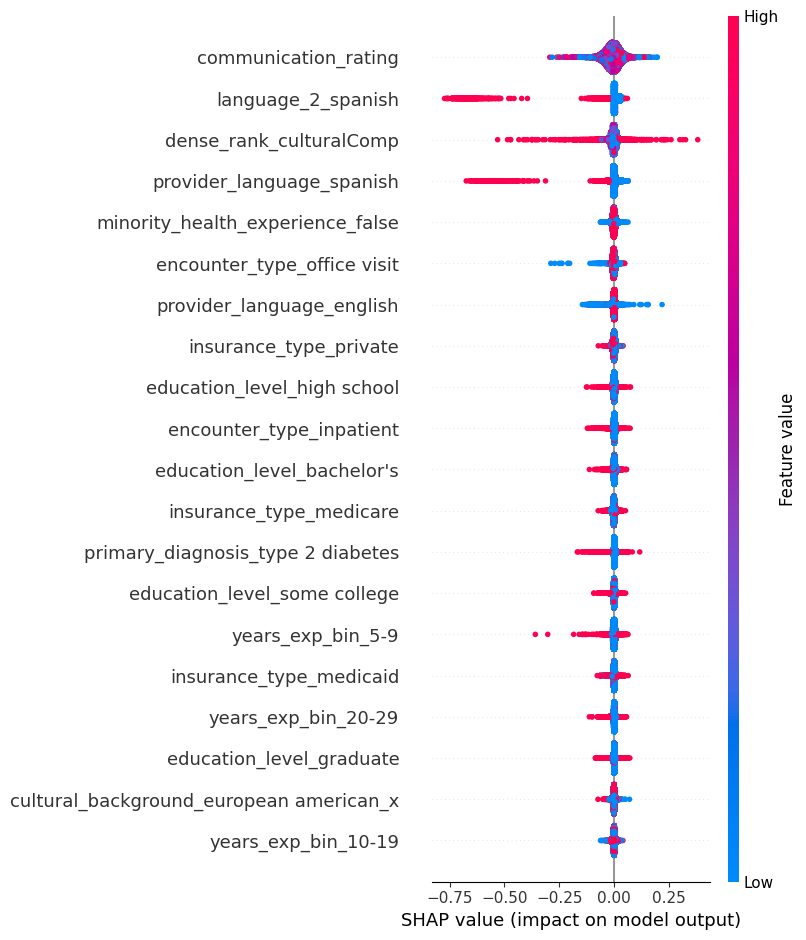

In [60]:
import shap
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

In [61]:
import numpy as np
import pandas as pd
import shap

# Assume:
#  - explainer = shap.TreeExplainer(xgb)
#  - X_test = your test features
#  - feature_cols = list of feature names

# 1) Compute SHAP values
shap_values = explainer.shap_values(X_test)

# 2) Compute mean absolute SHAP per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# 3) Normalize to percentage contribution
total = mean_abs_shap.sum()
influence_pct = (mean_abs_shap / total) * 100

# 4) Combine into a DataFrame
shap_importance = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": mean_abs_shap,
    "influence_pct": influence_pct
}).sort_values("influence_pct", ascending=False).reset_index(drop=True)

# 5) View top 20 features
print(shap_importance.head(20))

                                    feature  mean_abs_shap  influence_pct
0                      communication_rating       0.026745       9.259329
1                        language_2_spanish       0.010997       3.807347
2                   dense_rank_culturalComp       0.010273       3.556661
3                 provider_language_spanish       0.010070       3.486188
4          minority_health_experience_false       0.005704       1.974699
5               encounter_type_office visit       0.004881       1.689916
6                 provider_language_english       0.004707       1.629624
7                    insurance_type_private       0.004625       1.601165
8               education_level_high school       0.004567       1.581116
9                  encounter_type_inpatient       0.004561       1.578897
10               education_level_bachelor's       0.004400       1.523190
11                  insurance_type_medicare       0.004350       1.505852
12        primary_diagnosis_type 2 dia

In [62]:
import xgboost as xgb
import joblib

# Assume 'model' is your trained XGBRanker instance

# Save the model using joblib
joblib.dump(best_xgb, 'xgbranker_model.joblib')


['xgbranker_model.joblib']

In [ ]:
import joblib

# Load the model
loaded_model = joblib.load('xgbranker_model.joblib')